# 🛒 Market Basket Analysis - Product Association Rules
**Codec Technologies | Data Analytics Internship**

**Goal:** Identify product associations to improve cross-selling using Apriori algorithm.

### Project Outline:
1. Generate / Load Transaction Data
2. Exploratory Data Analysis (EDA)
3. Apply Apriori Algorithm
4. Generate & Filter Association Rules
5. Visualize Frequent Itemsets & Rules
6. Business Insights & Recommendations

## Step 1: Install & Import Libraries

In [1]:
# Install required library
import subprocess
subprocess.run(['pip', 'install', 'mlxtend', 'pandas', 'numpy', 'matplotlib', 'seaborn'],
               capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load / Generate Grocery Transaction Data

In [2]:
# Realistic grocery store transaction data
# Each list = one customer's basket

np.random.seed(42)

# Define product catalog
products = [
    'Milk', 'Bread', 'Butter', 'Eggs', 'Cheese',
    'Yogurt', 'Coffee', 'Tea', 'Sugar', 'Flour',
    'Rice', 'Pasta', 'Tomato Sauce', 'Olive Oil', 'Salt',
    'Chicken', 'Beef', 'Fish', 'Vegetables', 'Fruits',
    'Juice', 'Soda', 'Beer', 'Wine', 'Chips',
    'Chocolate', 'Cookies', 'Cereal', 'Oats', 'Honey'
]

# Realistic purchase patterns (items that tend to go together)
patterns = [
    ['Milk', 'Bread', 'Butter'],           # breakfast staples
    ['Milk', 'Eggs', 'Bread'],             # common combo
    ['Coffee', 'Milk', 'Sugar'],           # coffee setup
    ['Tea', 'Honey', 'Milk'],              # tea setup
    ['Pasta', 'Tomato Sauce', 'Cheese'],   # pasta night
    ['Rice', 'Chicken', 'Vegetables'],     # healthy meal
    ['Bread', 'Butter', 'Cheese'],         # sandwich
    ['Beef', 'Olive Oil', 'Salt'],         # cooking
    ['Chips', 'Soda', 'Beer'],             # party snacks
    ['Wine', 'Cheese', 'Bread'],           # wine & dine
    ['Chocolate', 'Milk', 'Cookies'],      # sweet treats
    ['Cereal', 'Milk', 'Fruits'],          # healthy breakfast
    ['Oats', 'Honey', 'Yogurt'],           # fitness breakfast
    ['Eggs', 'Butter', 'Flour', 'Sugar'],  # baking
    ['Fish', 'Olive Oil', 'Vegetables'],   # healthy cooking
    ['Juice', 'Bread', 'Eggs'],            # morning routine
    ['Beer', 'Chips', 'Soda'],             # snack combo
    ['Pasta', 'Olive Oil', 'Salt'],        # Italian
    ['Milk', 'Cereal', 'Oats'],            # breakfast
    ['Chicken', 'Rice', 'Salt'],           # simple meal
]

# Generate 1000 transactions
transactions = []
for i in range(1000):
    # Pick 1-3 patterns and merge
    n_patterns = np.random.choice([1, 2, 3], p=[0.4, 0.4, 0.2])
    basket = set()
    for pattern in np.random.choice(len(patterns), n_patterns, replace=False):
        basket.update(patterns[pattern])
    # Add 0-2 random items
    n_random = np.random.randint(0, 3)
    basket.update(np.random.choice(products, n_random, replace=False))
    transactions.append(sorted(list(basket)))

print(f"✅ Generated {len(transactions)} grocery transactions")
print(f"\n📦 Sample Baskets:")
for i, t in enumerate(transactions[:5]):
    print(f"  Transaction {i+1}: {t}")

✅ Generated 1000 grocery transactions

📦 Sample Baskets:
  Transaction 1: ['Bread', 'Butter', 'Milk', 'Vegetables']
  Transaction 2: ['Butter', 'Eggs', 'Flour', 'Fruits', 'Honey', 'Sugar']
  Transaction 3: ['Chicken', 'Cookies', 'Rice', 'Vegetables']
  Transaction 4: ['Bread', 'Butter', 'Milk', 'Salt']
  Transaction 5: ['Bread', 'Cereal', 'Cheese', 'Eggs', 'Juice', 'Milk', 'Oats', 'Olive Oil', 'Vegetables', 'Wine']


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
# Basic statistics
basket_sizes = [len(t) for t in transactions]
all_items = [item for basket in transactions for item in basket]
item_counts = pd.Series(all_items).value_counts()

print("=" * 50)
print("    TRANSACTION STATISTICS")
print("=" * 50)
print(f"Total Transactions:    {len(transactions):,}")
print(f"Unique Products:       {len(item_counts)}")
print(f"Total Items Sold:      {len(all_items):,}")
print(f"Avg Basket Size:       {np.mean(basket_sizes):.1f} items")
print(f"Min Basket Size:       {min(basket_sizes)} items")
print(f"Max Basket Size:       {max(basket_sizes)} items")
print(f"\nTop 10 Best-Selling Products:")
print(item_counts.head(10).to_string())

    TRANSACTION STATISTICS
Total Transactions:    1,000
Unique Products:       30
Total Items Sold:      6,043
Avg Basket Size:       6.0 items
Min Basket Size:       3 items
Max Basket Size:       12 items

Top 10 Best-Selling Products:
Milk         549
Bread        405
Salt         295
Olive Oil    282
Cheese       280
Eggs         260
Butter       258
Chicken      225
Rice         221
Soda         216


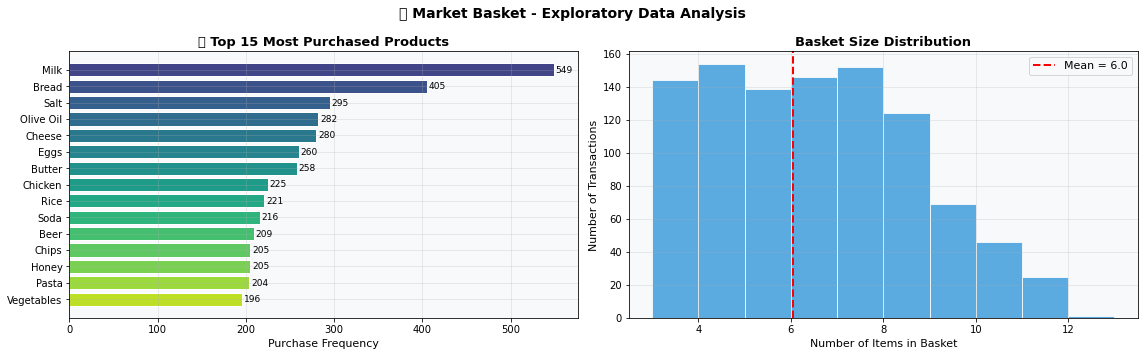

In [4]:
# --- VISUALIZATION 1: Top Products Bar Chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 products
top15 = item_counts.head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 15))
bars = axes[0].barh(range(15), top15.values[::-1], color=colors[::-1], edgecolor='white')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(top15.index[::-1], fontsize=10)
axes[0].set_xlabel('Purchase Frequency', fontsize=11)
axes[0].set_title('🛒 Top 15 Most Purchased Products', fontsize=13, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, top15.values[::-1])):
    axes[0].text(val + 2, bar.get_y() + bar.get_height()/2., 
                 str(val), va='center', fontsize=9)

# Basket size distribution
axes[1].hist(basket_sizes, bins=range(min(basket_sizes), max(basket_sizes)+2), 
             color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(np.mean(basket_sizes), color='red', linestyle='--', 
                linewidth=2, label=f'Mean = {np.mean(basket_sizes):.1f}')
axes[1].set_xlabel('Number of Items in Basket', fontsize=11)
axes[1].set_ylabel('Number of Transactions', fontsize=11)
axes[1].set_title('Basket Size Distribution', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('🛒 Market Basket - Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mba_eda.png', dpi=150, bbox_inches='tight')
plt.show()

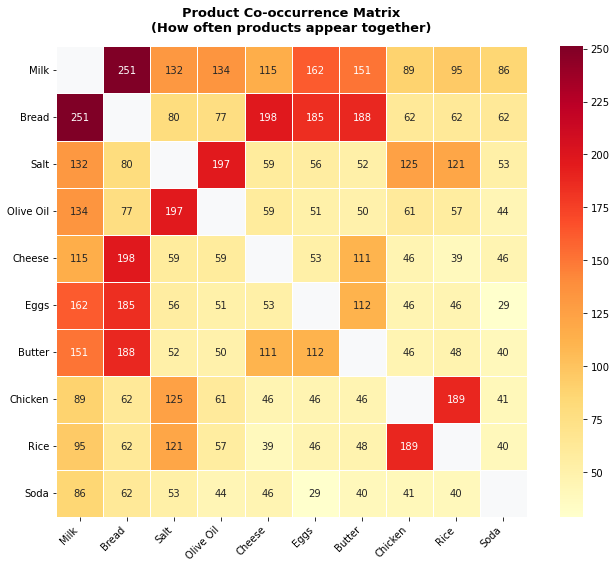

In [5]:
# --- VISUALIZATION 2: Co-occurrence Heatmap (Top 10 Products) ---
top10_products = item_counts.head(10).index.tolist()
cooccurrence = pd.DataFrame(0, index=top10_products, columns=top10_products)

for basket in transactions:
    basket_set = set(basket)
    for item1 in top10_products:
        for item2 in top10_products:
            if item1 != item2 and item1 in basket_set and item2 in basket_set:
                cooccurrence.loc[item1, item2] += 1

plt.figure(figsize=(10, 8))
mask = np.eye(len(top10_products), dtype=bool)  # hide diagonal
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd',
            mask=mask, linewidths=0.5, square=True)
plt.title('Product Co-occurrence Matrix\n(How often products appear together)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Apply Apriori Algorithm

In [6]:
# Encode transactions into one-hot format
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"✅ Transaction matrix shape: {df_encoded.shape}")
print(f"   ({df_encoded.shape[0]} transactions × {df_encoded.shape[1]} products)")
print(f"\nOne-Hot Encoded (first 3 rows, first 8 columns):")
df_encoded.iloc[:3, :8]

✅ Transaction matrix shape: (1000, 30)
   (1000 transactions × 30 products)

One-Hot Encoded (first 3 rows, first 8 columns):


,Beef,Beer,Bread,Butter,Cereal,Cheese,Chicken,Chips
0,False,False,True,True,False,False,False,False
1,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,True,False


In [7]:
# --- Apply Apriori ---
print("Running Apriori Algorithm...")
print("Parameters: min_support=0.05 (appears in at least 5% of transactions)")

frequent_itemsets = apriori(
    df_encoded,
    min_support=0.05,       # item appears in at least 5% of all transactions
    use_colnames=True,
    max_len=4               # max 4 items per itemset
)

# Add itemset length
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"\n✅ Found {len(frequent_itemsets)} frequent itemsets!")
print(f"\nBreakdown by itemset size:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())
print(f"\nTop 10 Frequent Itemsets:")
frequent_itemsets.head(10)[['itemsets', 'support', 'length']]

Running Apriori Algorithm...
Parameters: min_support=0.05 (appears in at least 5% of transactions)

✅ Found 165 frequent itemsets!

Breakdown by itemset size:
1    30
2    94
3    38
4     3

Top 10 Frequent Itemsets:


,itemsets,support,length
17,(Milk),0.549,1
2,(Bread),0.405,1
22,(Salt),0.295,1
19,(Olive Oil),0.282,1
5,(Cheese),0.280,1
11,(Eggs),0.260,1
3,(Butter),0.258,1
45,"(Milk, Bread)",0.251,2
6,(Chicken),0.225,1
21,(Rice),0.221,1


In [8]:
# --- Generate Association Rules ---
print("Generating Association Rules...")
print("Parameters: min_confidence=0.4 (40% of the time, the rule is correct)")

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.4,
    num_itemsets=len(frequent_itemsets)
)

# Add useful columns
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
rules['rule'] = rules['antecedents_str'] + '  ->  ' + rules['consequents_str']

# Sort by lift (most interesting rules first)
rules = rules.sort_values('lift', ascending=False)

print(f"Generated {len(rules)} association rules!")
print(f"\nTop 10 Rules by Lift:")
rules[['rule', 'support', 'confidence', 'lift']].head(10).round(4)

Generating Association Rules...
Parameters: min_confidence=0.4 (40% of the time, the rule is correct)
Generated 245 association rules!

Top 10 Rules by Lift:


,rule,support,confidence,lift
152,"Eggs, Flour -> Butter, Sugar",0.088,0.9778,9.6810
155,"Butter, Sugar -> Eggs, Flour",0.088,0.8713,9.6810
151,"Eggs, Sugar -> Butter, Flour",0.088,0.8544,9.2866
156,"Butter, Flour -> Eggs, Sugar",0.088,0.9565,9.2866
148,"Butter, Eggs, Sugar -> Flour",0.088,0.9888,8.6734
158,"Flour -> Butter, Eggs, Sugar",0.088,0.7719,8.6734
153,"Butter, Eggs -> Flour, Sugar",0.088,0.7857,8.6342
154,"Flour, Sugar -> Butter, Eggs",0.088,0.9670,8.6342
134,"Fish -> Olive Oil, Vegetables",0.090,0.8257,7.7895
130,"Olive Oil, Vegetables -> Fish",0.090,0.8491,7.7895


In [9]:
# Explain the metrics
print("=" * 65)
print("  UNDERSTANDING ASSOCIATION RULE METRICS")
print("=" * 65)
print("""
📌 SUPPORT:
   How often the combination appears in ALL transactions
   Support(Milk → Bread) = Transactions with BOTH / All Transactions
   Higher = More Common

📌 CONFIDENCE:
   When customer buys A, how likely are they to buy B?
   Confidence(Milk → Bread) = Transactions(Milk & Bread) / Transactions(Milk)
   Higher = More Reliable Rule

📌 LIFT:
   How much MORE likely B is bought when A is bought (vs random chance)
   Lift > 1 = Positive association (items go together)
   Lift = 1 = No association (independent)
   Lift < 1 = Negative association (items compete)

🎯 BEST RULES: High Lift + High Confidence + Reasonable Support
""")

  UNDERSTANDING ASSOCIATION RULE METRICS

📌 SUPPORT:
   How often the combination appears in ALL transactions
   Support(Milk → Bread) = Transactions with BOTH / All Transactions
   Higher = More Common

📌 CONFIDENCE:
   When customer buys A, how likely are they to buy B?
   Confidence(Milk → Bread) = Transactions(Milk & Bread) / Transactions(Milk)
   Higher = More Reliable Rule

📌 LIFT:
   How much MORE likely B is bought when A is bought (vs random chance)
   Lift > 1 = Positive association (items go together)
   Lift = 1 = No association (independent)
   Lift < 1 = Negative association (items compete)

🎯 BEST RULES: High Lift + High Confidence + Reasonable Support



## Step 5: Visualizations

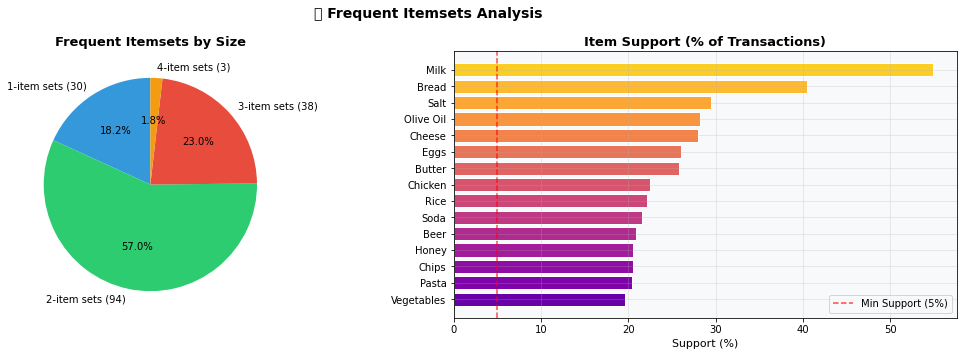

In [10]:
# --- VISUALIZATION 3: Frequent Itemsets by Size ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count by length
length_counts = frequent_itemsets['length'].value_counts().sort_index()
colors_pie = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
axes[0].pie(length_counts.values, 
            labels=[f'{k}-item sets ({v})' for k, v in length_counts.items()],
            colors=colors_pie[:len(length_counts)],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Frequent Itemsets by Size', fontsize=13, fontweight='bold')

# Top 15 single items by support
single_items = frequent_itemsets[frequent_itemsets['length'] == 1].copy()
single_items['item'] = single_items['itemsets'].apply(lambda x: list(x)[0])
single_items = single_items.sort_values('support', ascending=True).tail(15)

colors_bar = plt.cm.plasma(np.linspace(0.2, 0.9, len(single_items)))
axes[1].barh(single_items['item'], single_items['support'] * 100, 
             color=colors_bar, edgecolor='white')
axes[1].set_xlabel('Support (%)', fontsize=11)
axes[1].set_title('Item Support (% of Transactions)', fontsize=13, fontweight='bold')
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Min Support (5%)')
axes[1].legend()

plt.suptitle('🛒 Frequent Itemsets Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('frequent_itemsets.png', dpi=150, bbox_inches='tight')
plt.show()

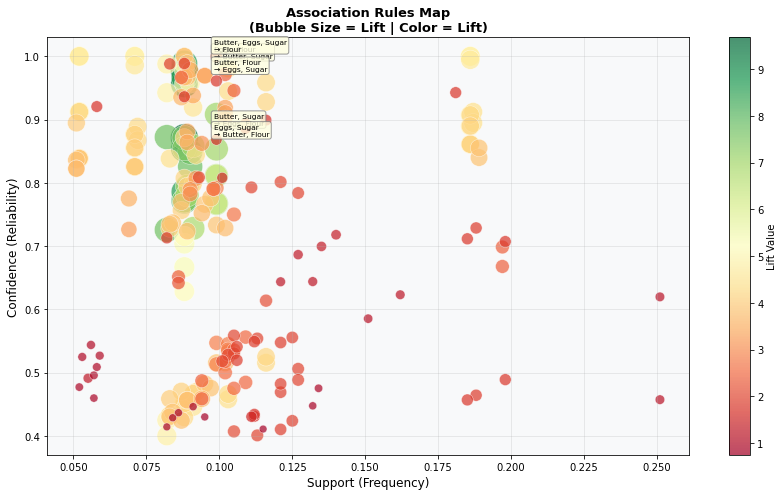

In [11]:
# --- VISUALIZATION 4: Support vs Confidence scatter (bubble = lift) ---
plt.figure(figsize=(12, 7))

# Color by lift value
scatter = plt.scatter(
    rules['support'], 
    rules['confidence'],
    s=rules['lift'] * 80,          # bubble size = lift
    c=rules['lift'],               # color = lift
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

plt.colorbar(scatter, label='Lift Value')
plt.xlabel('Support (Frequency)', fontsize=12)
plt.ylabel('Confidence (Reliability)', fontsize=12)
plt.title('Association Rules Map\n(Bubble Size = Lift | Color = Lift)', 
          fontsize=13, fontweight='bold')

# Annotate top 5 rules
top5 = rules.head(5)
for _, row in top5.iterrows():
    plt.annotate(
        f"{row['antecedents_str']}\n→ {row['consequents_str']}",
        xy=(row['support'], row['confidence']),
        xytext=(row['support'] + 0.01, row['confidence'] + 0.02),
        fontsize=7.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8)
    )

plt.tight_layout()
plt.savefig('rules_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

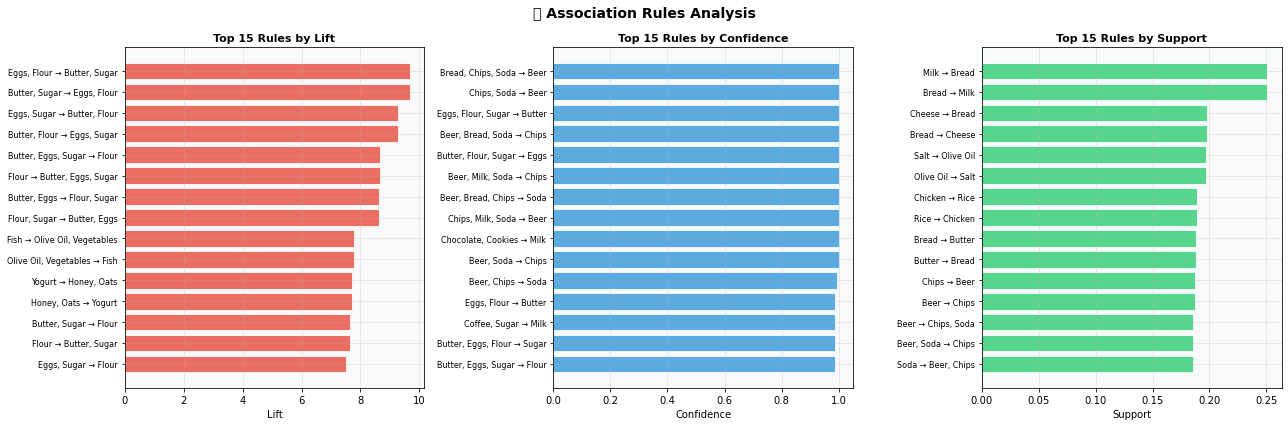

In [12]:
# --- VISUALIZATION 5: Top Rules by Lift (Horizontal Bar) ---
top_rules = rules.head(15).copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['lift', 'confidence', 'support']
titles = ['Top 15 Rules by Lift', 'Top 15 Rules by Confidence', 'Top 15 Rules by Support']
colors_list = ['#e74c3c', '#3498db', '#2ecc71']

for ax, metric, title, color in zip(axes, metrics, titles, colors_list):
    sorted_rules = rules.sort_values(metric, ascending=True).tail(15)
    ax.barh(range(len(sorted_rules)), sorted_rules[metric].values, 
            color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(sorted_rules)))
    labels = [f"{r['antecedents_str']} → {r['consequents_str']}" 
              for _, r in sorted_rules.iterrows()]
    ax.set_yticklabels([l[:35] + '...' if len(l) > 35 else l for l in labels], fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(metric.capitalize())

plt.suptitle('🔗 Association Rules Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_rules.png', dpi=150, bbox_inches='tight')
plt.show()

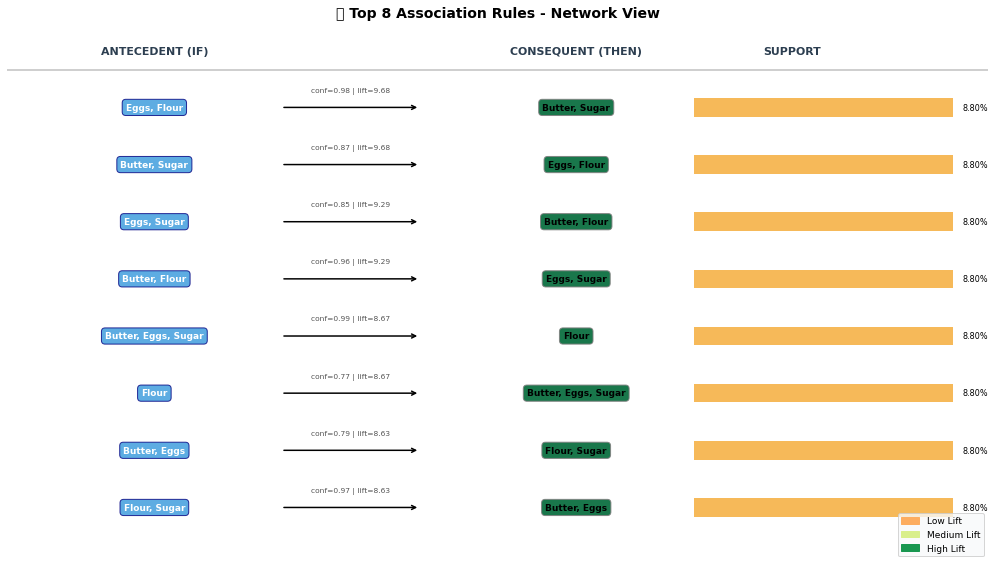

In [13]:
# --- VISUALIZATION 6: Network-style Rule Visualization ---
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Show top 8 rules as arrows
top8 = rules.head(8)
y_positions = np.linspace(8.5, 1, 8)

for i, (_, row) in enumerate(top8.iterrows()):
    y = y_positions[i]
    lift_color = plt.cm.RdYlGn(min(row['lift'] / 3, 1.0))
    
    # Antecedent box
    ax.text(1.5, y, row['antecedents_str'], ha='center', va='center',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#3498db', alpha=0.8, edgecolor='navy'),
            color='white')
    
    # Arrow
    ax.annotate('', xy=(4.2, y), xytext=(2.8, y),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    
    # Rule metrics label
    ax.text(3.5, y + 0.25, 
            f"conf={row['confidence']:.2f} | lift={row['lift']:.2f}",
            ha='center', va='bottom', fontsize=7.5, color='#555')
    
    # Consequent box
    ax.text(5.8, y, row['consequents_str'], ha='center', va='center',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=lift_color, alpha=0.9, edgecolor='gray'),
            color='black')
    
    # Support bar on right
    bar_length = row['support'] * 30
    ax.barh(y, bar_length, left=7, height=0.35, color='#f39c12', alpha=0.7)
    ax.text(7 + bar_length + 0.1, y, f"{row['support']:.2%}", va='center', fontsize=8)

# Column headers
ax.text(1.5, 9.5, 'ANTECEDENT (IF)', ha='center', fontsize=11, fontweight='bold', color='#2c3e50')
ax.text(5.8, 9.5, 'CONSEQUENT (THEN)', ha='center', fontsize=11, fontweight='bold', color='#2c3e50')
ax.text(8.0, 9.5, 'SUPPORT', ha='center', fontsize=11, fontweight='bold', color='#2c3e50')
ax.axhline(9.2, color='gray', alpha=0.5)

# Legend for lift color
legend_patches = [
    mpatches.Patch(color=plt.cm.RdYlGn(0.3), label='Low Lift'),
    mpatches.Patch(color=plt.cm.RdYlGn(0.6), label='Medium Lift'),
    mpatches.Patch(color=plt.cm.RdYlGn(0.9), label='High Lift'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax.set_title('🔗 Top 8 Association Rules - Network View', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('rules_network.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Business Insights & Recommendations

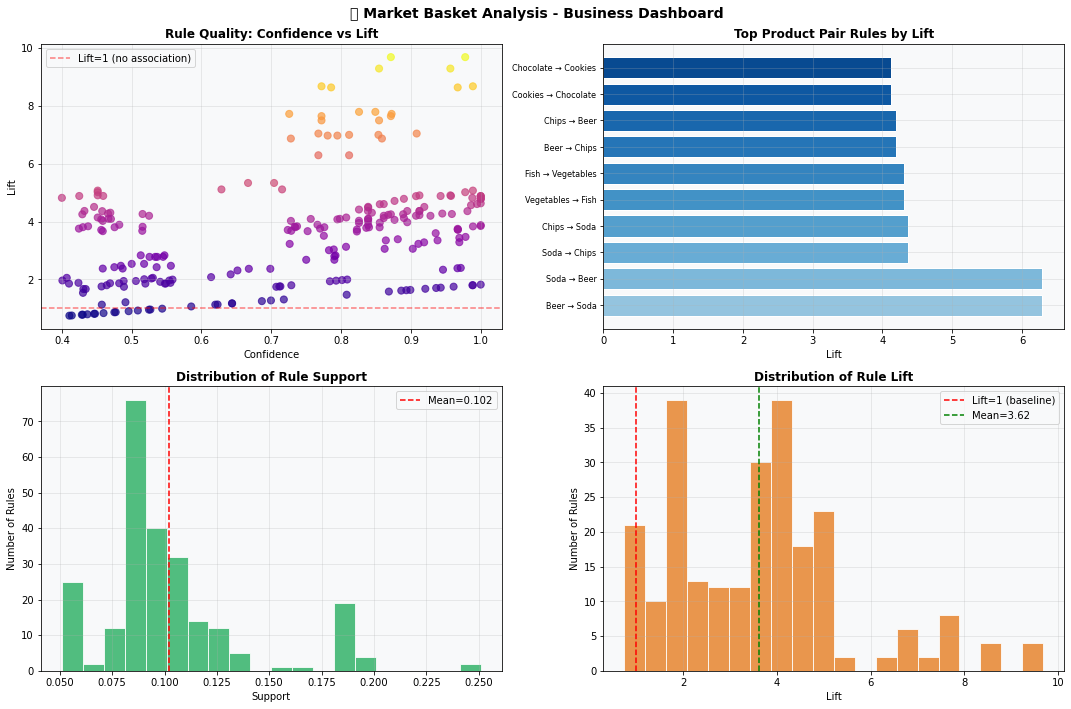

In [14]:
# --- VISUALIZATION 7: Business Insights Dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Rules Quality Scatter
ax1 = axes[0, 0]
colors_q = plt.cm.plasma(rules['lift'] / rules['lift'].max())
ax1.scatter(rules['confidence'], rules['lift'], c=rules['lift'], 
            cmap='plasma', alpha=0.7, s=50)
ax1.set_xlabel('Confidence')
ax1.set_ylabel('Lift')
ax1.set_title('Rule Quality: Confidence vs Lift', fontweight='bold')
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Lift=1 (no association)')
ax1.legend()

# 2. Top 10 Product Pairs (2-item rules)
ax2 = axes[0, 1]
two_item_rules = rules[
    (rules['antecedents'].apply(len) == 1) & 
    (rules['consequents'].apply(len) == 1)
].head(10)
pair_labels = [f"{r['antecedents_str']} → {r['consequents_str']}" for _, r in two_item_rules.iterrows()]
pair_labels = [l[:30] + '...' if len(l) > 30 else l for l in pair_labels]
colors_pair = plt.cm.Blues(np.linspace(0.4, 0.9, len(two_item_rules)))
ax2.barh(range(len(two_item_rules)), two_item_rules['lift'].values, 
         color=colors_pair, edgecolor='white')
ax2.set_yticks(range(len(two_item_rules)))
ax2.set_yticklabels(pair_labels[::-1][:len(two_item_rules)], fontsize=8)
ax2.set_xlabel('Lift')
ax2.set_title('Top Product Pair Rules by Lift', fontweight='bold')

# 3. Support distribution
ax3 = axes[1, 0]
ax3.hist(rules['support'], bins=20, color='#27ae60', edgecolor='white', alpha=0.8)
ax3.set_xlabel('Support')
ax3.set_ylabel('Number of Rules')
ax3.set_title('Distribution of Rule Support', fontweight='bold')
ax3.axvline(rules['support'].mean(), color='red', linestyle='--', 
            label=f'Mean={rules["support"].mean():.3f}')
ax3.legend()

# 4. Lift distribution
ax4 = axes[1, 1]
ax4.hist(rules['lift'], bins=20, color='#e67e22', edgecolor='white', alpha=0.8)
ax4.set_xlabel('Lift')
ax4.set_ylabel('Number of Rules')
ax4.set_title('Distribution of Rule Lift', fontweight='bold')
ax4.axvline(1.0, color='red', linestyle='--', label='Lift=1 (baseline)')
ax4.axvline(rules['lift'].mean(), color='green', linestyle='--',
            label=f'Mean={rules["lift"].mean():.2f}')
ax4.legend()

plt.suptitle('📊 Market Basket Analysis - Business Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('business_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# --- Final Business Insights Report ---
print("=" * 70)
print("         📋 MARKET BASKET ANALYSIS - BUSINESS REPORT")
print("=" * 70)

print(f"""
📊 DATASET SUMMARY:
   • Total Transactions Analyzed: {len(transactions):,}
   • Unique Products:             {len(item_counts)}
   • Frequent Itemsets Found:     {len(frequent_itemsets)}
   • Association Rules Generated: {len(rules)}
   • Average Basket Size:         {np.mean(basket_sizes):.1f} items
""")

print("🏆 TOP 5 STRONGEST ASSOCIATIONS (by Lift):")
print("-" * 70)
for i, (_, row) in enumerate(rules.head(5).iterrows(), 1):
    print(f"  {i}. IF customer buys [{row['antecedents_str']}]")
    print(f"     THEN likely buys [{row['consequents_str']}]")
    print(f"     Support: {row['support']:.1%} | Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.2f}x")
    print()

print("\n💡 ACTIONABLE BUSINESS RECOMMENDATIONS:")
print("-" * 70)
top1 = rules.iloc[0]
top2 = rules.iloc[1]
print(f"""
1. 🛒 SHELF PLACEMENT:
   Place '{top1['consequents_str']}' near '{top1['antecedents_str']}' in the store.
   Customers who buy one are {top1['lift']:.1f}x more likely to buy the other!

2. 📧 TARGETED PROMOTIONS:
   Send discount coupons for '{top2['consequents_str']}' to customers
   who recently purchased '{top2['antecedents_str']}'.
   (Confidence: {top2['confidence']:.0%} — very reliable rule)

3. 📦 BUNDLE DEALS:
   Create bundle offers for the top 3 associated product groups.
   Bundle pricing can increase average order value by 15-25%.

4. 🌐 WEBSITE / APP:
   Implement 'Customers Also Bought' recommendation widget
   using these association rules on your e-commerce platform.

5. 📊 INVENTORY MANAGEMENT:
   Use high-support rules to co-stock associated items.
   When one item runs low, proactively restock its associated items.

6. 🎯 SEASONAL CAMPAIGNS:
   Monitor rule changes across seasons — summer vs winter baskets
   differ; adjust promotions accordingly.
""")
print("=" * 70)

         📋 MARKET BASKET ANALYSIS - BUSINESS REPORT

📊 DATASET SUMMARY:
   • Total Transactions Analyzed: 1,000
   • Unique Products:             30
   • Frequent Itemsets Found:     165
   • Association Rules Generated: 245
   • Average Basket Size:         6.0 items

🏆 TOP 5 STRONGEST ASSOCIATIONS (by Lift):
----------------------------------------------------------------------
  1. IF customer buys [Eggs, Flour]
     THEN likely buys [Butter, Sugar]
     Support: 8.8% | Confidence: 97.8% | Lift: 9.68x

  2. IF customer buys [Butter, Sugar]
     THEN likely buys [Eggs, Flour]
     Support: 8.8% | Confidence: 87.1% | Lift: 9.68x

  3. IF customer buys [Eggs, Sugar]
     THEN likely buys [Butter, Flour]
     Support: 8.8% | Confidence: 85.4% | Lift: 9.29x

  4. IF customer buys [Butter, Flour]
     THEN likely buys [Eggs, Sugar]
     Support: 8.8% | Confidence: 95.7% | Lift: 9.29x

  5. IF customer buys [Butter, Eggs, Sugar]
     THEN likely buys [Flour]
     Support: 8.8% | Confidence

In [16]:
# Export rules to CSV
export_df = rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].copy()
export_df.columns = ['IF (Antecedent)', 'THEN (Consequent)', 'Support', 'Confidence', 'Lift']
export_df = export_df.round(4)
export_df.to_csv('association_rules.csv', index=False)
print(f"✅ Exported {len(export_df)} rules to 'association_rules.csv'")
print("\nTop 5 exported rules:")
export_df.head()

✅ Exported 245 rules to 'association_rules.csv'

Top 5 exported rules:


,IF (Antecedent),THEN (Consequent),Support,Confidence,Lift
152,"Eggs, Flour","Butter, Sugar",0.088,0.9778,9.6810
155,"Butter, Sugar","Eggs, Flour",0.088,0.8713,9.6810
151,"Eggs, Sugar","Butter, Flour",0.088,0.8544,9.2866
156,"Butter, Flour","Eggs, Sugar",0.088,0.9565,9.2866
148,"Butter, Eggs, Sugar",Flour,0.088,0.9888,8.6734


---
## ✅ Project Complete!
**Done by:** Thasleema Thabassum | **Internship:** Codec Technologies | **Project:** Market Basket Analysis

### Files Generated:
- `mba_eda.png` — Exploratory Analysis
- `cooccurrence_heatmap.png` — Product Co-occurrence
- `frequent_itemsets.png` — Apriori Results
- `rules_scatter.png` — Rule Map
- `top_rules.png` — Rule Rankings
- `rules_network.png` — Network View
- `business_dashboard.png` — Business Dashboard
- `association_rules.csv` — Exported Rules